<a href="https://colab.research.google.com/github/fadeeva/portfoli_o_o_ptimisation/blob/main/Step_02__Classical_Markowitz%20_Optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd

from scipy import optimize

import datetime as dt
import yfinance as yf

import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use('ggplot')

In [2]:
rng = np.random.default_rng(42)

# Classical Markowitz optimization

In [3]:
tickers  = ['AMD', 'AMZN', 'BAC', 'META', 'AVGO', 'TER', 'NVDA']

df = yf.download(tickers, dt.datetime(2022, 1, 1), dt.datetime.now(), auto_adjust=True)
df = df['Close']
df = pd.concat([df, df.pct_change().add_suffix('_simp_ret')], axis=1)
df.dropna(inplace=True)

df.head()

[*********************100%***********************]  7 of 7 completed


Ticker,AMD,AMZN,AVGO,BAC,META,NVDA,TER,AMD_simp_ret,AMZN_simp_ret,AVGO_simp_ret,BAC_simp_ret,META_simp_ret,NVDA_simp_ret,TER_simp_ret
Date,,,,,,,,,,,,,,
2022-01-04,144.419998,167.522003,62.018631,42.882721,333.600494,29.197762,163.409271,-0.038738,-0.016916,0.011458,0.039195,-0.005937,-0.027589,0.001625
2022-01-05,136.149994,164.356995,59.437748,42.158913,321.348114,27.517069,157.388718,-0.057264,-0.018893,-0.041615,-0.016879,-0.036728,-0.057562,-0.036843
2022-01-06,136.229996,163.253998,58.885899,43.007820,329.565887,28.089260,160.561020,0.000588,-0.006711,-0.009284,0.020136,0.025573,0.020794,0.020156
2022-01-07,132.000000,162.554001,57.233089,43.946068,328.901764,27.161194,155.444031,-0.031050,-0.004288,-0.028068,0.021816,-0.002015,-0.033040,-0.031869
2022-01-10,132.000000,161.485992,57.418896,43.722668,325.214111,27.313713,153.813660,0.000000,-0.006570,0.003246,-0.005084,-0.011212,0.005615,-0.010488


## Weighted Portfolio Return

In [4]:
amounts = rng.integers(low=10, high=50, size=len(tickers))

returns = df[[ticker+'_simp_ret' for ticker in tickers]]
returns.columns = tickers

position = df[tickers] * amounts
weights = position.div(position.sum(axis=1), axis=0)


portfolio_returns = (weights * returns).sum(axis=1)
portfolio_cummulative = (1 + portfolio_returns).cumprod() - 1

portfolio_cummulative.iloc[-1]

np.float64(2.478162495401532)

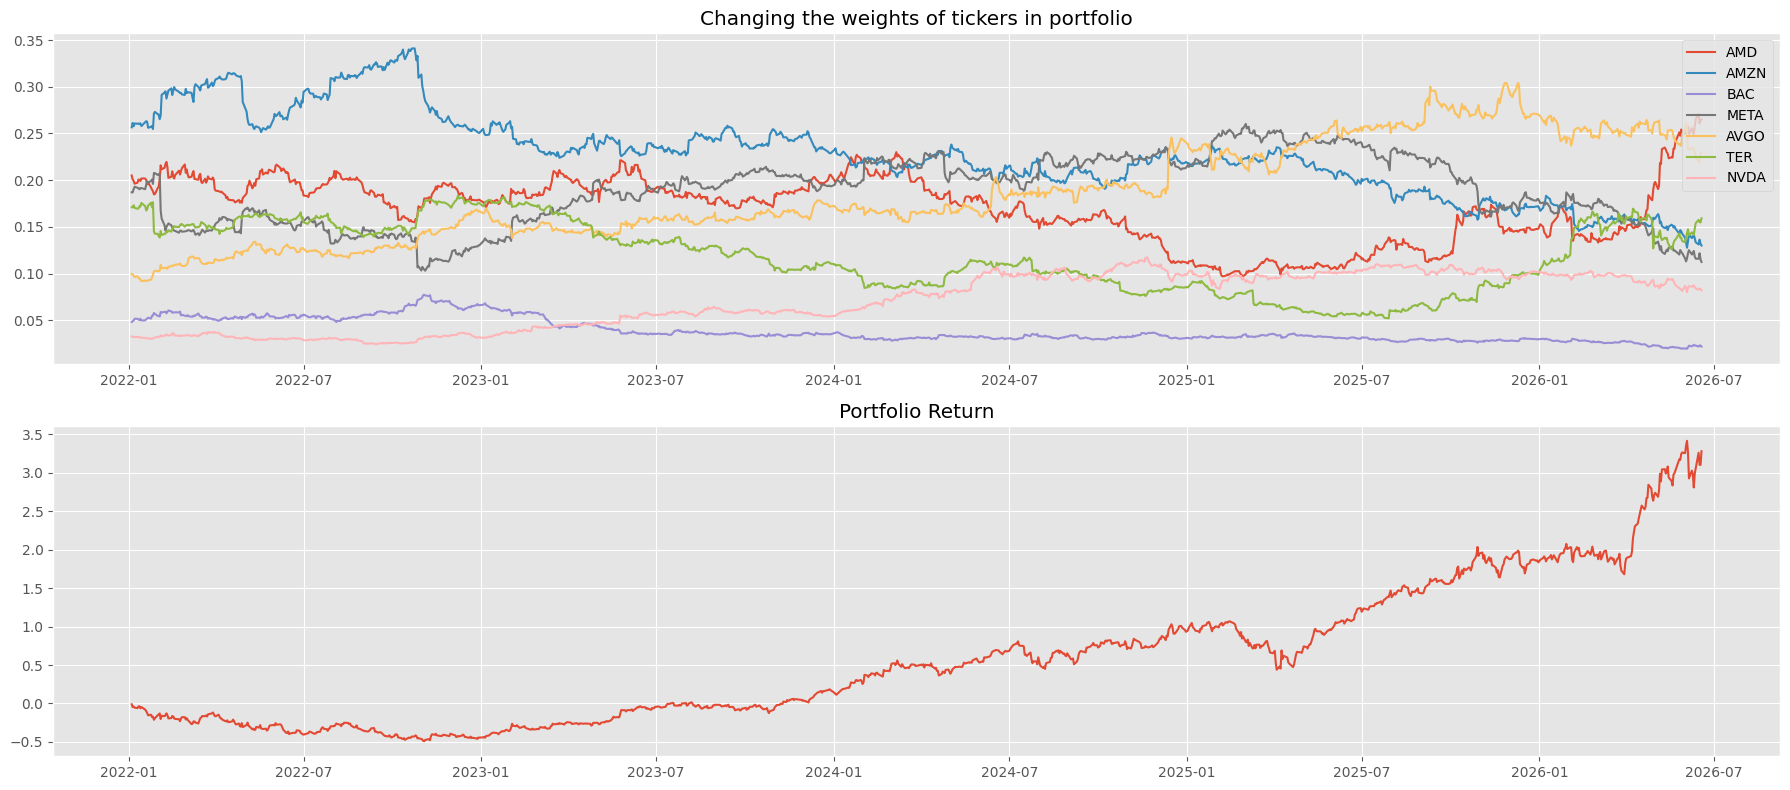

In [ ]:
fig, axs = plt.subplots(2, 1, figsize=(18, 8))

axs[0].plot(weights, label=tickers)
axs[0].set_title('Changing the weights of tickers in portfolio')
axs[0].legend()

axs[1].plot(portfolio_cummulative)
axs[1].set_title('Portfolio Return')

plt.tight_layout()

## Portfolio risk

$
\sigma_p = \sqrt{w^T\Sigma w}
$

In [5]:
w = weights.iloc[-1].values
cov_matrix = returns.cov() * 252

portfolio_variance = w.T @ cov_matrix @ w
portfolio_risk = np.sqrt(portfolio_variance)

portfolio_risk

np.float64(0.3614071023187127)

In [14]:
risk_contributions = pd.DataFrame({
    'ticker': tickers,
    'weight': w,
    'volatility': np.sqrt(np.diag(cov_matrix)),
    'risk_contribution': w * np.sqrt(np.diag(cov_matrix))
})

risk_contributions['risk_share'] = risk_contributions['risk_contribution'] / portfolio_risk

risk_contributions

,ticker,weight,volatility,risk_contribution,risk_share
0,AMD,0.103519,0.570821,0.059091,0.163502
1,AMZN,0.144859,0.367599,0.053250,0.147341
2,BAC,0.029981,0.270086,0.008097,0.022405
3,META,0.230945,0.457281,0.105607,0.292210
4,AVGO,0.164580,0.454197,0.074752,0.206836
5,TER,0.285529,0.521099,0.148789,0.411693
6,NVDA,0.040587,0.524918,0.021305,0.058950


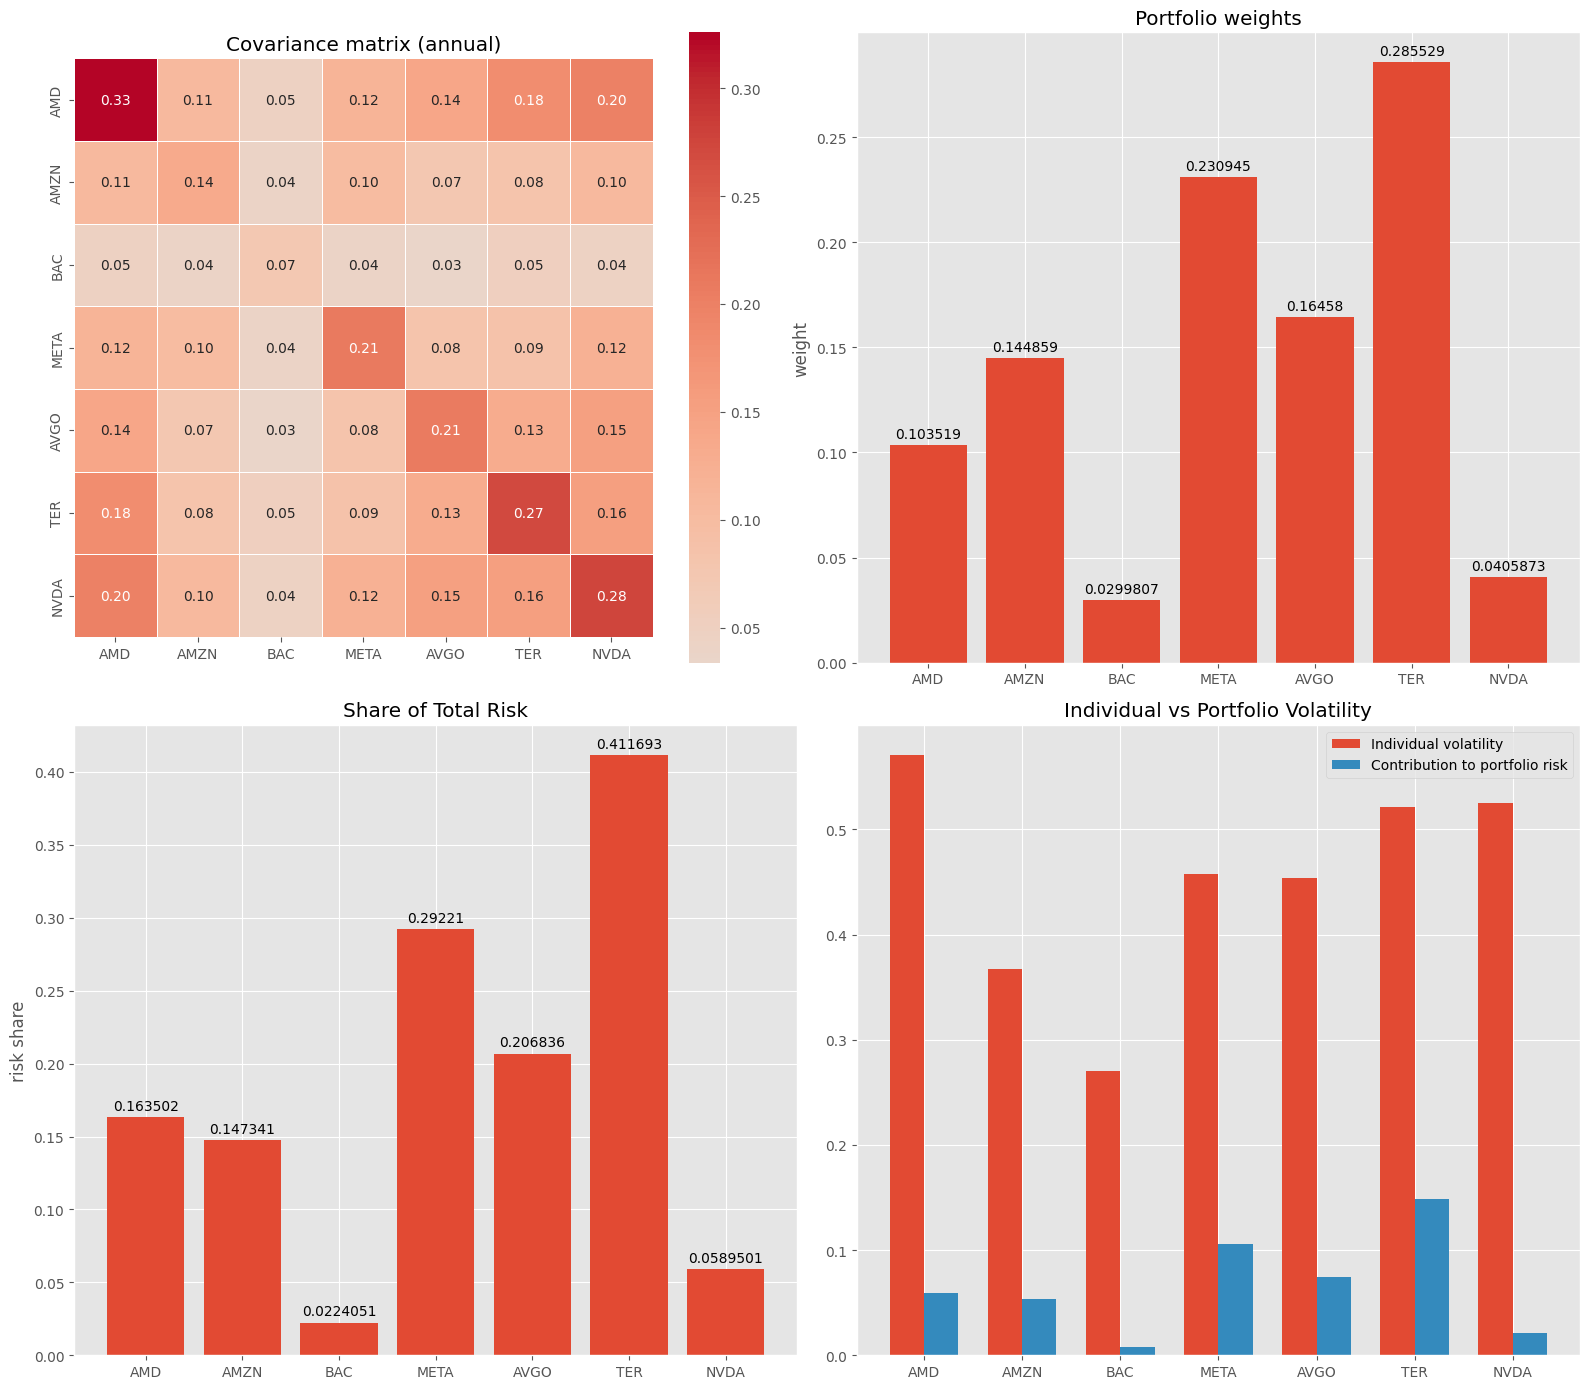

In [33]:
fig, axs = plt.subplots(2, 2, figsize=(16, 14))

sns.heatmap(
    cov_matrix, annot=True,
    cmap='coolwarm', center=0,
    fmt='.2f', square=True,
    linewidths=0.5, ax=axs[0, 0])\
    .set_title('Covariance matrix (annual)')

bars = axs[0, 1].bar(tickers, w)
axs[0, 1].bar_label(bars, padding=3)
axs[0, 1].set_title('Portfolio weights')
axs[0, 1].set_ylabel('weight')

bars = axs[1, 0].bar(tickers, risk_contributions['risk_share'])
axs[1, 0].bar_label(bars, padding=3)
axs[1, 0].set_title('Share of Total Risk')
axs[1, 0].set_ylabel('risk share')

x = np.arange(len(tickers))
width = 0.35
axs[1, 1].bar(x - width/2, risk_contributions['volatility'], width, label='Individual volatility')
axs[1, 1].bar(x + width/2, risk_contributions['risk_contribution'], width, label='Contribution to portfolio risk')
axs[1, 1].set_xticks(x)
axs[1, 1].set_xticklabels(tickers)
axs[1, 1].set_title('Individual vs Portfolio Volatility')
axs[1, 1].legend()

plt.tight_layout()
